In [1]:


import pandas as pd
import numpy as np
import json
import plotly.express as px
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import ast

# Load the dataset
df = pd.read_csv("Worldwide Travel Cities Dataset (Ratings and Climate).csv")



In [2]:
# Safely parse JSON-like strings into Python dictionaries
df['avg_temp_monthly'] = df['avg_temp_monthly'].apply(ast.literal_eval)

# Expand monthly temperatures into separate columns
monthly_temps = df['avg_temp_monthly'].apply(pd.Series)

# Rename columns for clarity (assuming 12 values for 12 months)
monthly_temps.columns = ['Jan_temp', 'Feb_temp', 'Mar_temp', 'Apr_temp', 'May_temp', 'Jun_temp',
                         'Jul_temp', 'Aug_temp', 'Sep_temp', 'Oct_temp', 'Nov_temp', 'Dec_temp']

# Merge back with original dataframe and drop original column
df = pd.concat([df.drop(columns=['avg_temp_monthly']), monthly_temps], axis=1)

# Preview the cleaned dataframe
print(df.head())

                                     id            city    country  \
0  c54acf38-3029-496b-8c7a-8343ad82785c           Milan      Italy   
1  0bd12654-ed64-424e-a044-7bc574bcf078  Yasawa Islands       Fiji   
2  73036cda-9134-46fc-a2c6-807782d59dfb        Whistler     Canada   
3  3872c9c0-6b6e-49e1-9743-f46bfe591b86      Guanajuato     Mexico   
4  e1ebc1b6-8798-422d-847a-22016faff3fd        Surabaya  Indonesia   

          region                                  short_description  \
0         europe  Chic streets lined with fashion boutiques, his...   
1        oceania  Crystal-clear waters, secluded beaches, and vi...   
2  north_america  Snow-capped peaks and lush forests create a se...   
3  north_america  Winding cobblestone streets and colorful facad...   
4           asia  Bustling streets filled with the aroma of loca...   

    latitude   longitude                      ideal_durations budget_level  \
0  45.464194    9.189635            ["Short trip","One week"]       Luxury

In [3]:
user_input = {
    'themes': ['Nature', 'Cuisine', 'Adventure'],
    'budget': 'Mid-range',
    'month': 'August'
}


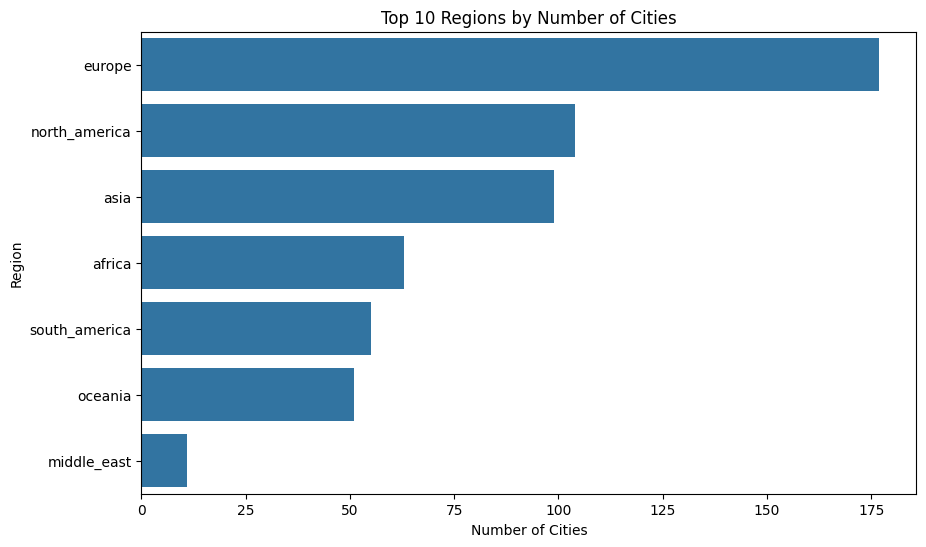

In [ ]:
# Analyze the distribution of cities across different regions
plt.figure(figsize=(10,6))
top_regions = df['region'].value_counts().head(10)
sns.barplot(x=top_regions.values, y=top_regions.index)
plt.title('Top 10 Regions by Number of Cities')
plt.xlabel('Number of Cities')
plt.ylabel('Region')
plt.show()



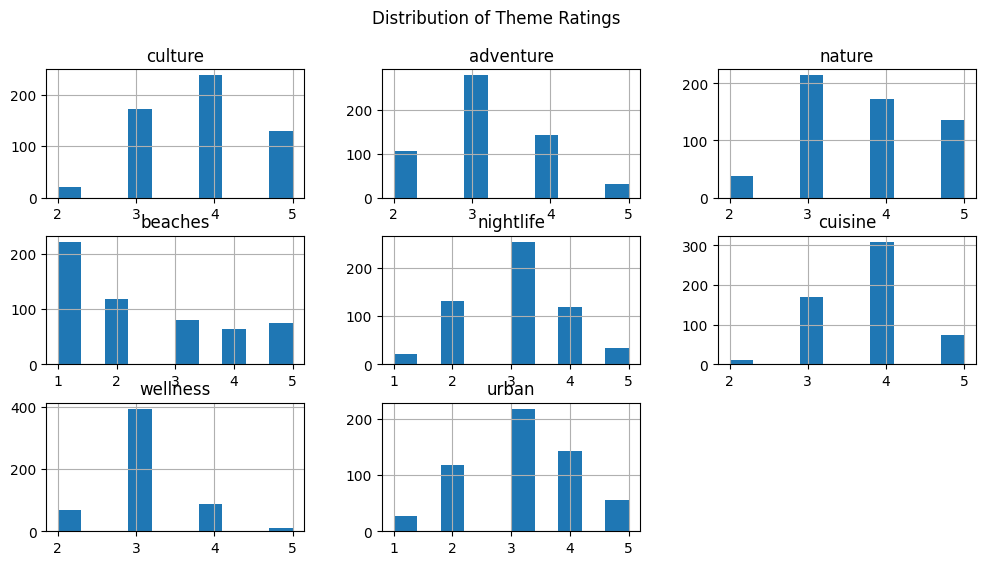

In [ ]:
# Analyze the distribution of theme ratings
rating_columns = ['culture', 'adventure', 'nature', 'beaches', 'nightlife', 'cuisine', 'wellness', 'urban']

# Only use columns that exist in the dataframe
existing_rating_columns = [col for col in rating_columns if col in df.columns]

df[existing_rating_columns].hist(figsize=(12, 6))
plt.suptitle('Distribution of Theme Ratings')
plt.show()

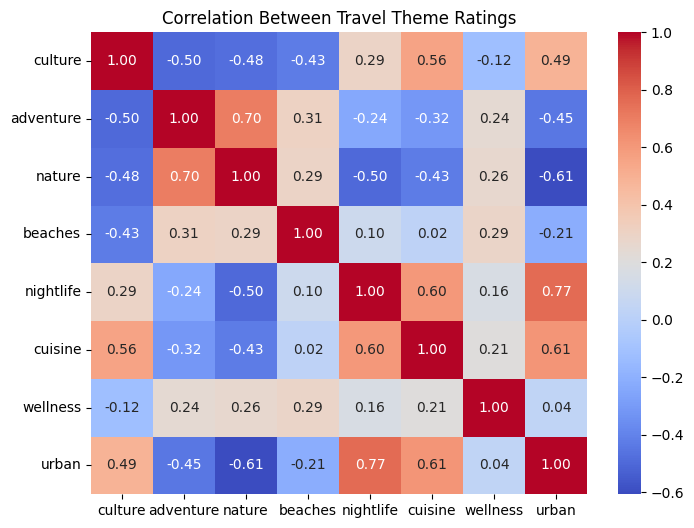

In [6]:
plt.figure(figsize=(8,6))
sns.heatmap(df[existing_rating_columns].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Between Travel Theme Ratings")
plt.show()


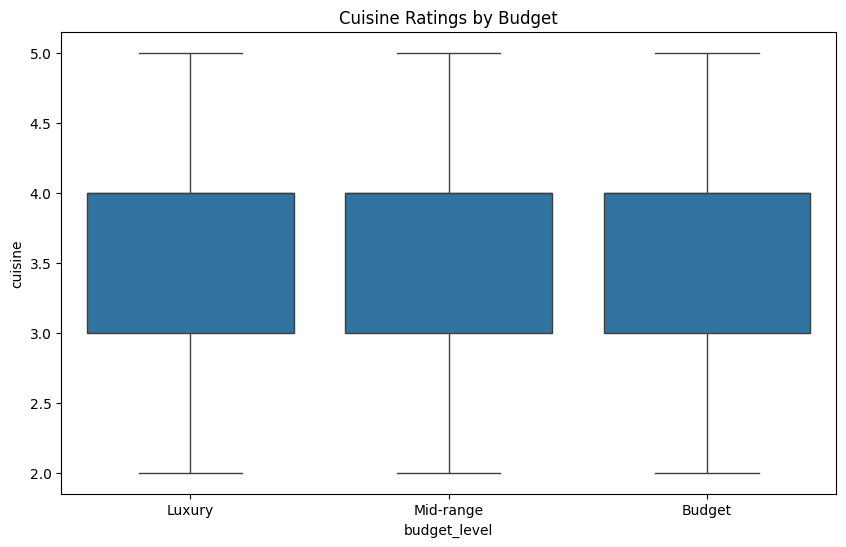

In [ ]:
# Analyze the relationship between budget and cuisine ratings
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='budget_level', y='cuisine')
plt.title('Cuisine Ratings by Budget')
plt.show()

In [8]:
# Use correct column names and extract temperature features for the selected month
selected_month = user_input['month']  # e.g., 'August'
month_col = selected_month[:3].capitalize() + '_temp'  # e.g., 'Aug_temp'

# Extract avg, min, max temperature for the selected month
df['avg_temp'] = df[month_col].apply(lambda x: x['avg'])
df['min_temp'] = df[month_col].apply(lambda x: x['min'])
df['max_temp'] = df[month_col].apply(lambda x: x['max'])

features = [
    'culture', 'adventure', 'nature', 'beaches', 'nightlife',
    'cuisine', 'wellness', 'urban',
    'avg_temp', 'min_temp', 'max_temp'
]

X = df[features]


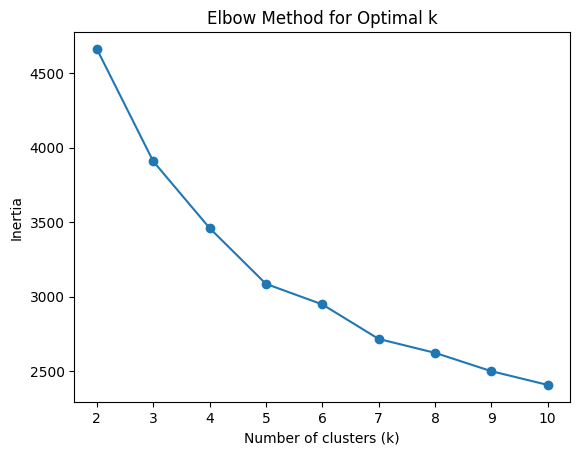

In [ ]:
# Standardize the features before applying PCA
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []
k_range = range(2, 11)
# Use the Elbow Method to find the optimal number of clusters
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(k_range, inertia, marker='o')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.show()

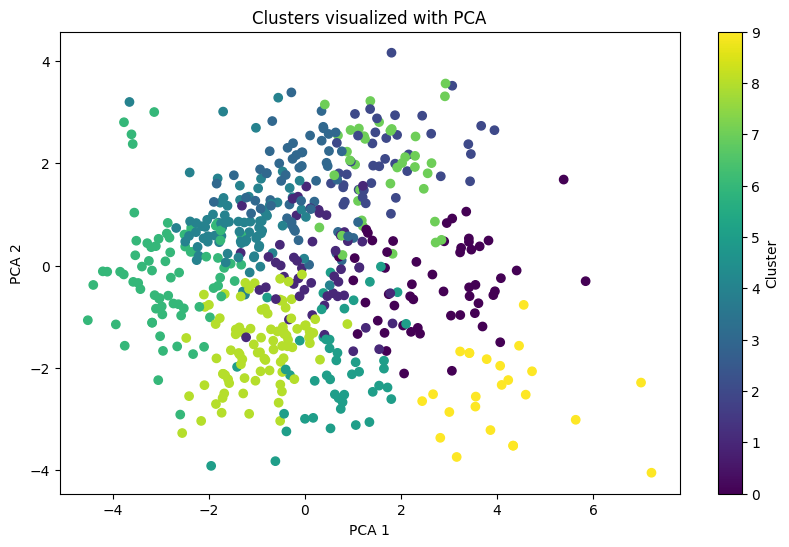

In [ ]:
from sklearn.decomposition import PCA
# Apply PCA to reduce dimensionality for visualization
pca = PCA(n_components=2)
components = pca.fit_transform(X_scaled)

df['PCA1'] = components[:, 0]
df['PCA2'] = components[:, 1]

# Assigning cluster labels to the existing dataframe
df['Cluster'] = kmeans.predict(X_scaled)

# Visualize the clusters using PCA components
plt.figure(figsize=(10,6))
plt.scatter(df['PCA1'], df['PCA2'], c=df['Cluster'], cmap='viridis')
plt.title('Clusters visualized with PCA')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.colorbar(label='Cluster')
plt.show()


In [13]:
country_theme_summary = df.groupby('country')[['culture', 'adventure', 'nature', 'beaches', 'nightlife', 'cuisine', 'wellness', 'urban']].mean().sort_values('culture', ascending=False)

country_theme_summary.head()

,culture,adventure,nature,beaches,nightlife,cuisine,wellness,urban
country,,,,,,,,
Hong Kong,5.0,3.0,3.0,2.0,5.0,5.0,3.0,5.0
Iran,5.0,3.0,3.0,1.0,3.0,4.0,3.0,4.0
Guatemala,5.0,3.0,4.0,1.0,3.0,4.0,3.0,3.0
Malta,5.0,2.0,3.0,3.0,3.0,4.0,3.0,3.0
Cuba,5.0,3.0,3.5,3.0,3.5,4.0,2.5,2.5


In [14]:
city_counts = df['country'].value_counts().sort_values(ascending=False)
print(city_counts.head(10))


country
United States     50
Italy             19
Australia         17
Mexico            15
France            15
Canada            14
United Kingdom    14
Spain             12
Germany           11
Portugal          11
Name: count, dtype: int64


In [ ]:
# Identify top cities for each theme based on user input
top_culture_by_region = df.loc[df.groupby('region')['culture'].idxmax()][['region', 'city', 'culture']]
print(top_culture_by_region)
# Repeat for other themes
top_culture_by_nightlife = df.loc[df.groupby('region')['nightlife'].idxmax()][['region', 'city', 'nightlife']]
print(top_culture_by_nightlife)

top_culture_by_cuisine = df.loc[df.groupby('region')['cuisine'].idxmax()][['region', 'city', 'cuisine']]
print(top_culture_by_cuisine)

top_culture_by_nature = df.loc[df.groupby('region')['nature'].idxmax()][['region', 'city', 'nature']]
print(top_culture_by_nature)

           region        city  culture
53         africa         Fès        5
14           asia       Bagan        5
0          europe       Milan        5
31    middle_east       Petra        5
3   north_america  Guanajuato        5
40        oceania   Melbourne        5
71  south_america   Cartagena        5
            region            city  nightlife
162         africa       Cape Town          4
23            asia           Seoul          5
16          europe       Amsterdam          5
410    middle_east           Dubai          5
17   north_america        New York          5
40         oceania       Melbourne          4
50   south_america  Rio de Janeiro          5
            region       city  cuisine
403         africa  Marrakesh        5
23            asia      Seoul        5
0           europe      Milan        5
115    middle_east      Amman        4
17   north_america   New York        5
40         oceania  Melbourne        5
261  south_america  Sao Paulo        5
        

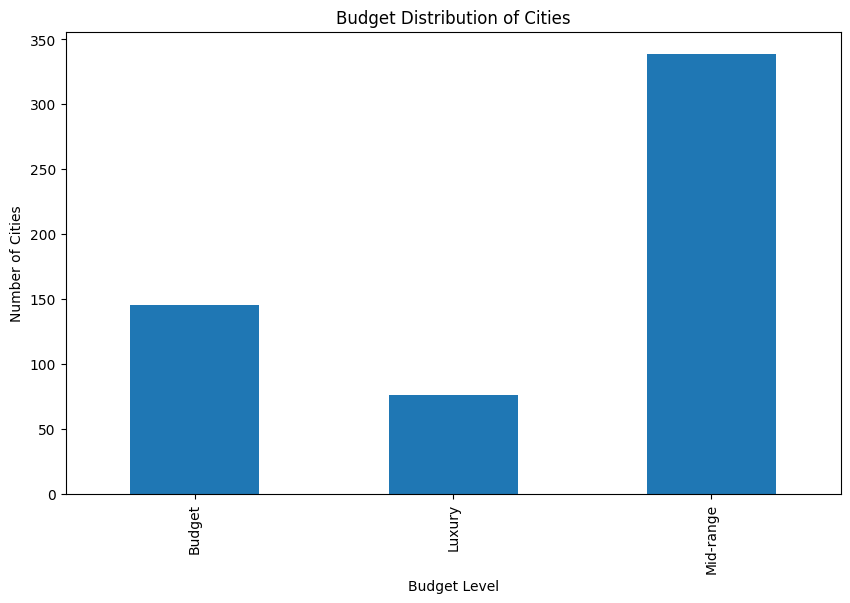

In [ ]:
# Analyze the distribution of budget levels
budget_distribution = df['budget_level'].value_counts().sort_index()
budget_distribution.plot(kind='bar', figsize=(10, 6))
plt.title('Budget Distribution of Cities')
plt.xlabel('Budget Level')
plt.ylabel('Number of Cities')
plt.show()  

In [17]:
#Select relevant features and handle missing values
features = ['culture', 'adventure', 'nature', 'beaches', 'nightlife',
            'cuisine', 'wellness', 'urban',]
df_selected = df[features].copy()
df_selected = df_selected.fillna(df_selected.mean())

In [18]:
df['Cluster'] = kmeans.labels_

# Use the correct column name 'Cluster' and valid feature columns
cluster_summary = df.groupby('Cluster')[features].mean()
print(cluster_summary)

          culture  adventure    nature   beaches  nightlife   cuisine  \
Cluster                                                                 
0        3.500000   4.074074  4.796296  1.833333   2.203704  3.055556   
1        3.634615   2.692308  3.346154  1.519231   2.500000  3.096154   
2        3.024390   3.829268  4.585366  3.170732   1.926829  3.000000   
3        3.285714   3.535714  3.964286  4.553571   3.553571  4.000000   
4        4.421687   2.807229  3.409639  1.867470   2.674699  4.084337   
5        4.000000   3.239130  3.739130  2.804348   3.521739  4.021739   
6        4.513158   2.815789  2.763158  2.144737   4.171053  4.644737   
7        2.973684   3.868421  4.894737  3.921053   2.500000  3.605263   
8        4.322222   2.444444  3.111111  1.388889   3.411111  4.011111   
9        3.083333   4.250000  4.750000  2.041667   2.541667  3.166667   

         wellness     urban  
Cluster                      
0        3.092593  2.203704  
1        2.288462  2.788462  
2  

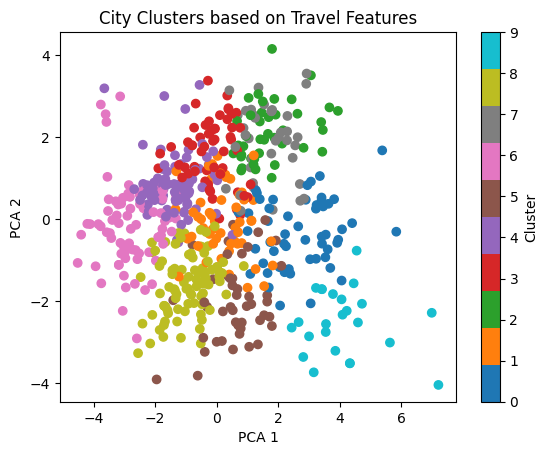

In [ ]:
# Visualize clusters using PCA components based on their features
import matplotlib.pyplot as plt

# Assuming 'components' contains the PCA-transformed features and 'kmeans.labels_' contains the cluster labels
plt.scatter(components[:, 0], components[:, 1], c=kmeans.labels_, cmap='tab10')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.title('City Clusters based on Travel Features')
plt.colorbar(label='Cluster')
plt.show()


In [ ]:
# Scaling features to be used for machine learning tasks
rating_columns = ['culture', 'adventure', 'nature', 'beaches', 'nightlife', 'cuisine', 'wellness', 'urban']

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
# Scale the features and create a new DataFrame for the scaled features
X_scaled = scaler.fit_transform(df[rating_columns])



In [ ]:


# User input for travel preferences
rating_columns = [ 'culture', 'adventure', 'nature', 'beaches', 'nightlife', 'cuisine', 'wellness', 'urban']
from sklearn.metrics.pairwise import cosine_similarity

# Collect user preferences for each theme
print("Rate the following themes from 0 (not important) to 5 (very important):")
user_input = {}
for col in rating_columns:
    while True:
        try:
            val = float(input(f"{col}: "))
            if 0 <= val <= 5:
                user_input[col] = val
                break
            else:
                print("Enter a value between 0 and 5.")
        except ValueError:
            print("Invalid input. Please enter a number.")

# Converting input to vector and scale
user_vec = np.array([user_input[col] for col in rating_columns]).reshape(1, -1)
user_vec_scaled = scaler.transform(user_vec)

# Calculating the cosine similarity
similarities = cosine_similarity(user_vec_scaled, X_scaled)[0]

# Attaching the similarity scores
df['Similarity'] = similarities

# Show top recommendations
top_n = 20
top_matches = df.sort_values(by='Similarity', ascending=False).head(top_n)

print(f"\nTop {top_n} Travel Recommendations:\n")
print(top_matches[['city', 'country', 'Similarity'] + rating_columns])

Rate the following themes from 0 (not important) to 5 (very important):

Top 20 Travel Recommendations:

                city               country  Similarity  culture  adventure  \
190            Miami         United States    0.921105        3          3   
460  Fort Lauderdale         United States    0.867581        3          3   
414      Los Angeles         United States    0.841753        4          3   
451   Punta del Este               Uruguay    0.796670        3          3   
43        Bridgetown              Barbados    0.765404        3          3   
500        Vilamoura              Portugal    0.765404        3          3   
107           Monaco                Monaco    0.761740        4          2   
509           Cancun                Mexico    0.707010        3          4   
553     Viña del Mar                 Chile    0.700896        3          3   
410            Dubai  United Arab Emirates    0.693056        4          4   
317             Hvar               Cr

/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
# Prepare data for machine learning
x = city_features = df[rating_columns]
y = [1 if match else 0 for match in df['Similarity'] > 0.5]  # Example threshold for matching
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
# Train a Random Forest Classifier
model = RandomForestClassifier()
model.fit(X_train, y_train)
# Make predictions and evaluate the model
predictions = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, predictions))

Accuracy: 0.9642857142857143


In [ ]:
import streamlit as st
st.title("Travel Destination Recommender")
st.write("Find your next travel destination based on your preferences!")

